# 🏒 VIZER NHL — 01 · Maintenance des Données

Ce notebook télécharge et met à jour les CSVs 2025 depuis [Moneypuck](https://peter-tanner.com/moneypuck/).

**Ordre d'exécution des notebooks :**
1. ▶️ **01_Maintenance** ← vous êtes ici
2. 02_Agregation
3. 03_Entrainement
4. 04_Inference

In [1]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import os
import gc
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display, HTML

# ── Configuration ─────────────────────────────────────────────────────────────
DRIVE_PATH = '/home/noxtheteenager/Documents/Projets/vizer_info_model/hockey/nhl'

TEAM_DATA    = os.path.join(DRIVE_PATH, 'all_teams.csv')
GOALIES_HIST = os.path.join(DRIVE_PATH, 'goalies_2008_2024.csv')
LINES_HIST   = os.path.join(DRIVE_PATH, 'lines_2008_2024.csv')
SKATERS_HIST = os.path.join(DRIVE_PATH, 'skaters_2008_2024.csv')

FILES_2025 = {
    'skaters': {
        'url':  'https://peter-tanner.com/moneypuck/downloads/seasonPlayersSummary/skaters/2025.zip',
        'path': os.path.join(DRIVE_PATH, 'skaters_2025.csv'),
    },
    'lines': {
        'url':  'https://peter-tanner.com/moneypuck/downloads/seasonPlayersSummary/lines/2025.zip',
        'path': os.path.join(DRIVE_PATH, 'lines_2025.csv'),
    },
    'goalies': {
        'url':  'https://peter-tanner.com/moneypuck/downloads/seasonPlayersSummary/goalies/2025.zip',
        'path': os.path.join(DRIVE_PATH, 'goalies_2025.csv'),
    },
}

print(f'✅ Configuration chargée — {datetime.now().strftime("%d/%m/%Y %H:%M")}')

✅ Configuration chargée — 14/05/2026 23:22


## 📁 Vérification des fichiers historiques

In [2]:
files_to_check = {
    'all_teams.csv':        TEAM_DATA,
    'goalies_2008-2024':    GOALIES_HIST,
    'lines_2008-2024':      LINES_HIST,
    'skaters_2008-2024':    SKATERS_HIST,
}

rows = []
for label, path in files_to_check.items():
    exists = os.path.exists(path)
    size_mb = os.path.getsize(path) / 1e6 if exists else 0
    rows.append({'Fichier': label, 'Statut': '✅ Présent' if exists else '❌ Manquant',
                 'Taille': f'{size_mb:.1f} MB'})

display(pd.DataFrame(rows).style.hide(axis='index'))

Fichier,Statut,Taille
all_teams.csv,✅ Présent,124.1 MB
goalies_2008-2024,✅ Présent,44.7 MB
lines_2008-2024,✅ Présent,663.7 MB
skaters_2008-2024,✅ Présent,2620.1 MB


## ⬇️ Téléchargement incrémental 2025

Seuls les `gameId` absents du fichier local sont ajoutés.

In [3]:
results = []

for cat, info in FILES_2025.items():
    status, n_added, error_msg = '?', 0, ''
    try:
        r = requests.get(info['url'], timeout=45)
        r.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            csv_name = [f for f in z.namelist() if f.endswith('.csv')][0]
            df_new = pd.read_csv(z.open(csv_name))

        if os.path.exists(info['path']):
            existing_ids = set(pd.read_csv(info['path'], usecols=['gameId'])['gameId'].unique())
            df_to_add = df_new[~df_new['gameId'].isin(existing_ids)]
            if not df_to_add.empty:
                df_to_add.to_csv(info['path'], mode='a', header=False, index=False)
                n_added = len(df_to_add)
                status = f'✅ +{n_added} lignes'
            else:
                status = '✓ Déjà à jour'
                n_added = 0
        else:
            df_new.to_csv(info['path'], index=False)
            n_added = len(df_new)
            status = f'🆕 Créé ({n_added} lignes)'

    except Exception as e:
        status = '❌ Erreur'
        error_msg = str(e)[:60]

    size_mb = os.path.getsize(info['path']) / 1e6 if os.path.exists(info['path']) else 0
    results.append({
        'Catégorie': cat.upper(), 'Statut': status,
        'Lignes ajoutées': n_added, 'Taille finale': f'{size_mb:.1f} MB',
        'Erreur': error_msg,
    })
    print(f'{cat.upper():<10} {status}')

gc.collect()
df_res = pd.DataFrame(results)
display(df_res.drop(columns=['Erreur']).style.hide(axis='index'))

SKATERS    ✓ Déjà à jour
LINES      ✓ Déjà à jour
GOALIES    ✓ Déjà à jour


Catégorie,Statut,Lignes ajoutées,Taille finale
SKATERS,✓ Déjà à jour,0,169.3 MB
LINES,✓ Déjà à jour,0,44.6 MB
GOALIES,✓ Déjà à jour,0,2.8 MB


## 📊 Statistiques des données 2025

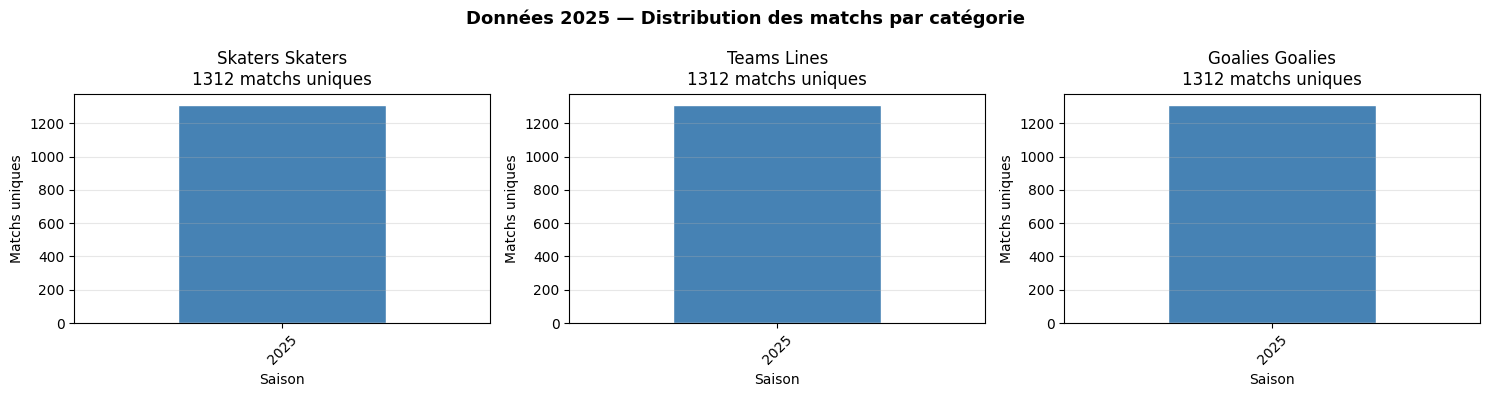

✅ Graphique sauvegardé → maintenance_stats.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Données 2025 — Distribution des matchs par catégorie', fontsize=13, fontweight='bold')

categories = ['skaters', 'lines', 'goalies']
titles     = ['Skaters️ Skaters', 'Teams Lines', 'Goalies Goalies']

for ax, cat, title in zip(axes, categories, titles):
    path = FILES_2025[cat]['path']
    if not os.path.exists(path):
        ax.text(0.5, 0.5, 'Fichier absent', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        continue

    df = pd.read_csv(path, usecols=['gameId', 'season'] if 'season' in
                     pd.read_csv(path, nrows=1).columns else ['gameId'])
    n_games = df['gameId'].nunique()

    if 'season' in df.columns:
        season_counts = df.groupby('season')['gameId'].nunique()
        season_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
        ax.set_xlabel('Saison')
    else:
        ax.bar(['2025'], [n_games], color='steelblue', edgecolor='white')

    ax.set_title(f'{title}\n{n_games} matchs uniques')
    ax.set_ylabel('Matchs uniques')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('maintenance_stats.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé → maintenance_stats.png')

## ✅ Résumé

Le pipeline de maintenance est terminé. Lance maintenant **02_Agregation.ipynb**.

In [5]:
# Résumé final
total_added = sum(r['Lignes ajoutées'] for r in results)
print(f'📅 Maintenance terminée : {datetime.now().strftime("%d/%m/%Y %H:%M")}')
print(f'📥 Total lignes ajoutées : {total_added:,}')
print(f'\n➡️  Lance maintenant 02_Agregation.ipynb')

📅 Maintenance terminée : 14/05/2026 23:24
📥 Total lignes ajoutées : 0

➡️  Lance maintenant 02_Agregation.ipynb
